# ClusterStratifiedKFold: cluster-stratified spatial CV

`ClusterStratifiedKFold` fits a user-supplied clusterer (HDBSCAN, OPTICS, KMeans, ...) to the input locations, then partitions each cluster's members into `n_splits` parts. Every test fold draws proportionally from every cluster, so each fold spans all clusters rather than holding out a single region.

This is the spatial analogue of `StratifiedKFold` where the strata are spatial clusters discovered at fit time.

In [1]:
import geodatasets
import geopandas
import numpy
import matplotlib.pyplot as plt
import colormaps
from sklearn.cluster import HDBSCAN

from geovalidate import ClusterStratifiedKFold

chicago = geopandas.read_file(geodatasets.get_path("geoda.chicago_health")).to_crs("EPSG:32616")
chicago["income"] = chicago["PerCInc14"].fillna(chicago["PerCInc14"].median())
print(f"n = {len(chicago)} community areas")

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n = 77 community areas


## Basic usage

Pass any sklearn-compatible clusterer. `ClusterStratifiedKFold` clones it internally, fits to the input coordinates, then stratifies each cluster across folds.

In [2]:
ckf = ClusterStratifiedKFold(HDBSCAN(min_cluster_size=4), n_splits=5, random_state=0)
splits = list(ckf.split(chicago))

print(f"discovered {ckf.n_clusters_} cluster labels (including noise if any)")
print(f"label histogram: {numpy.bincount(ckf.labels_ - ckf.labels_.min())}")
print(f"fold sizes:      {[len(te) for _, te in splits]}")

discovered 3 cluster labels (including noise if any)
label histogram: [29 31 17]
fold sizes:      [17, 16, 15, 15, 14]


/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


### Visualize clusters and one example fold

Left: HDBSCAN clusters (noise in grey). Right: which community area is in the test set vs the train set for fold 0.

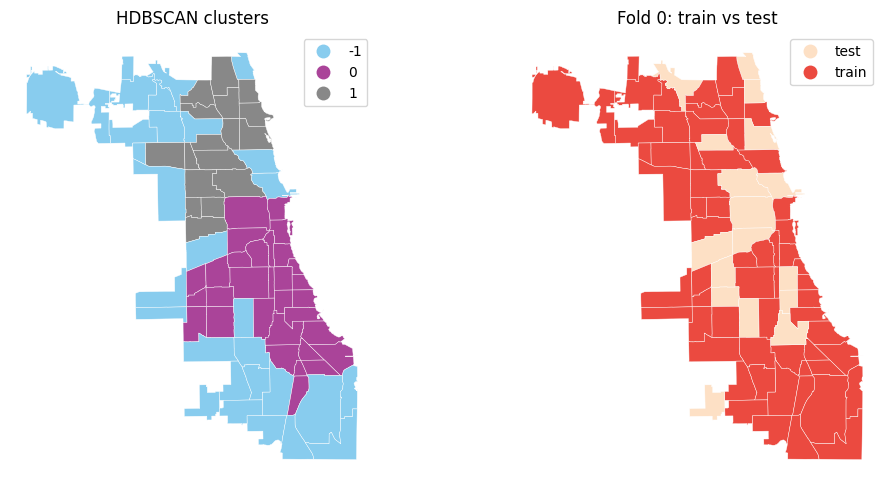

In [3]:
chicago_view = chicago.copy()
chicago_view["cluster"] = ckf.labels_

fold0_train, fold0_test = splits[0]
chicago_view["fold0_role"] = "train"
chicago_view.loc[chicago_view.index[fold0_test], "fold0_role"] = "test"

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
chicago_view.plot(column="cluster", cmap=colormaps.safe, categorical=True, legend=True, ax=axes[0], edgecolor="white", linewidth=0.3)
axes[0].set_title("HDBSCAN clusters")
axes[0].set_axis_off()

chicago_view.plot(column="fold0_role", cmap=colormaps.peach, categorical=True, legend=True, ax=axes[1], edgecolor="white", linewidth=0.3)
axes[1].set_title("Fold 0: train vs test")
axes[1].set_axis_off()
plt.tight_layout()

## Noise handling

Density-based clusterers (HDBSCAN, OPTICS) label outlier points with `-1`. `ClusterStratifiedKFold` exposes three policies:

- `noise='stratify'` (default): distribute noise across folds like any other cluster.
- `noise='drop'`: exclude noise from both train and test.
- `noise='train_only'`: noise is in every train set, never in any test set.


In [4]:
for mode in ("stratify", "drop", "train_only"):
    ckf_m = ClusterStratifiedKFold(HDBSCAN(min_cluster_size=4), n_splits=5, noise=mode, random_state=0)
    splits_m = list(ckf_m.split(chicago))
    n_noise = int((ckf_m.labels_ == -1).sum())
    train0, test0 = splits_m[0]
    train_has_noise = int(numpy.isin(numpy.flatnonzero(ckf_m.labels_ == -1), train0).sum())
    test_has_noise = int(numpy.isin(numpy.flatnonzero(ckf_m.labels_ == -1), test0).sum())
    print(f"noise={mode:11s}  n_noise={n_noise}  fold0 train has {train_has_noise}, test has {test_has_noise}")

noise=stratify     n_noise=29  fold0 train has 23, test has 6
noise=drop         n_noise=29  fold0 train has 0, test has 0
noise=train_only   n_noise=29  fold0 train has 29, test has 0


/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## Pre-fitted clusterer

If you have already fit a clusterer (e.g. to inspect it, tune it, or share it across folds and other code), pass it in directly: `ClusterStratifiedKFold` will detect the `labels_` attribute and skip refitting.

In [5]:
coords = numpy.column_stack([chicago.geometry.centroid.x, chicago.geometry.centroid.y])
fitted = HDBSCAN(min_cluster_size=4).fit(coords)
print(f"pre-fit found {len(set(fitted.labels_))} labels")

ckf_pre = ClusterStratifiedKFold(fitted, n_splits=5, random_state=0)
splits_pre = list(ckf_pre.split(chicago))

assert ckf_pre.clusterer_ is fitted, "pre-fitted clusterer should be used as-is"
print(f"fold sizes: {[len(te) for _, te in splits_pre]}")

pre-fit found 3 labels
fold sizes: [17, 16, 15, 15, 14]


/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
